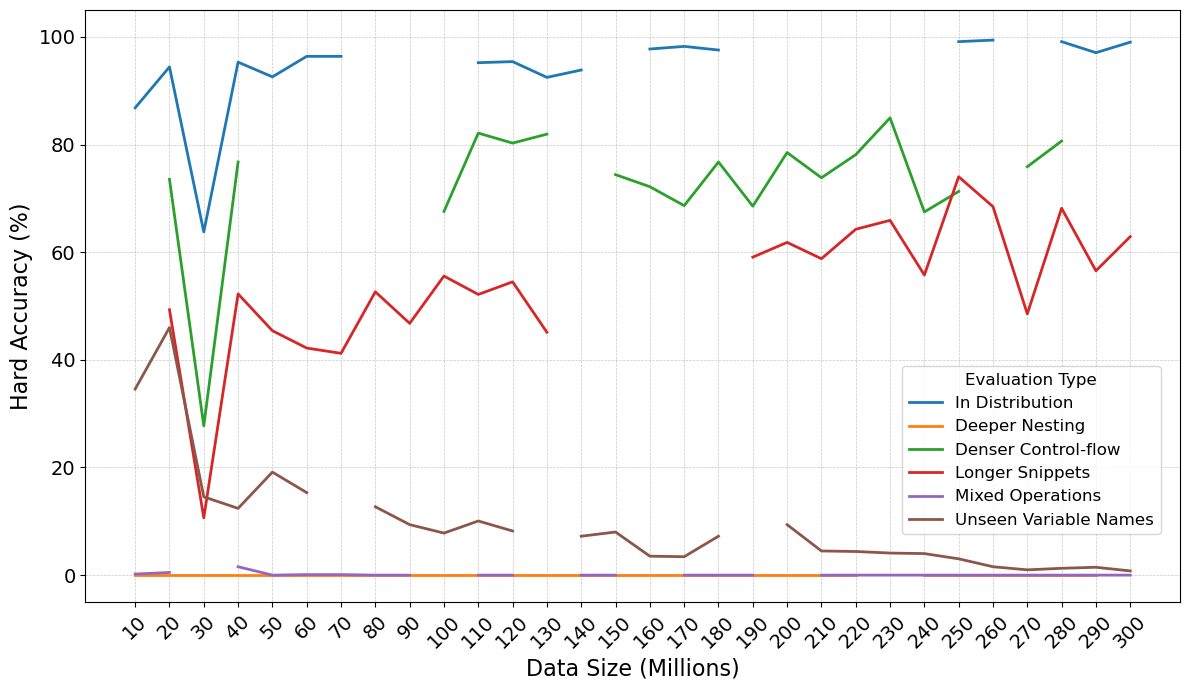

In [1]:
# %% [markdown]
# ### 1. Imports and Configuration
# Run this cell to import dependencies and set up the parsing logic.

# %%
import os
import re
import matplotlib.pyplot as plt

# Configuration
results_dir = "./results"

# List of checkpoints in order
checkpoints = [
    "checkpoint_0.03.pth", "checkpoint_0.07.pth", "checkpoint_0.10.pth", "checkpoint_0.13.pth",
    "checkpoint_0.17.pth", "checkpoint_0.20.pth", "checkpoint_0.23.pth", "checkpoint_0.27.pth",
    "checkpoint_0.30.pth", "checkpoint_0.33.pth", "checkpoint_0.37.pth", "checkpoint_0.40.pth",
    "checkpoint_0.43.pth", "checkpoint_0.47.pth", "checkpoint_0.50.pth", "checkpoint_0.53.pth",
    "checkpoint_0.57.pth", "checkpoint_0.60.pth", "checkpoint_0.63.pth", "checkpoint_0.67.pth",
    "checkpoint_0.70.pth", "checkpoint_0.73.pth", "checkpoint_0.77.pth", "checkpoint_0.80.pth",
    "checkpoint_0.83.pth", "checkpoint_0.87.pth", "checkpoint_0.90.pth", "checkpoint_0.93.pth",
    "checkpoint_0.97.pth", "checkpoint_1.00.pth"
]

# The tasks we want to plot
tasks = [
    "ID", 
    "OOD_Deeper", 
    "OOD_Denser", 
    "OOD_Longer_snippets", 
    "OOD_Mixed_ops",
    "OOD_Hidden_variables"
]

# %% [markdown]
# ### 2. Data Extraction
# This parses all the `model-eval.log` files and extracts the hard accuracy.

# %%
# Dictionary to hold lists of accuracies for each task
accuracy_data = {task: [] for task in tasks}

# Regex to find: |hard-accuracy: 953 = 93.07% |
regex_pattern = r"hard-accuracy:\s*\d+\s*=\s*([0-9.]+)%"

for ckpt in checkpoints:
    for task in tasks:
        folder_name = f"eval_jobs1_{ckpt}_{task}"
        log_path = os.path.join(results_dir, folder_name, "model-eval.log")
        
        acc = None
        if os.path.exists(log_path):
            with open(log_path, "r", encoding="utf-8") as f:
                content = f.read()
                # Find the accuracy using regex
                match = re.search(regex_pattern, content)
                if match:
                    acc = float(match.group(1))
        
        # If the file is missing or failed to parse, use None so matplotlib skips it cleanly
        accuracy_data[task].append(acc)

# %% [markdown]
# ### 3. Visualization
# Generating the chart with lines matching the requested visual theme.

# %%
# ==========================================
# FONT SIZE CONFIGURATION PALETTE
# Adjust these values to change text sizes
# ==========================================
axis_title_size = 16
tick_label_size = 14
legend_title_size = 12
legend_text_size = 12
# ==========================================

# X-axis data size (10 million per checkpoint, up to 300 million)
x_values = [i * 10 for i in range(1, len(checkpoints) + 1)]

# Mapping raw task names to the legend titles you requested
legend_labels = {
    "ID": "In Distribution",
    "OOD_Deeper": "Deeper Nesting",
    "OOD_Denser": "Denser Control-flow",
    "OOD_Longer_snippets": "Longer Snippets",
    "OOD_Mixed_ops": "Mixed Operations",
    "OOD_Hidden_variables": "Unseen Variable Names"
}

plt.figure(figsize=(12, 7))

# Plot each task (no markers, solid lines)
for task in tasks:
    plt.plot(
        x_values, 
        accuracy_data[task], 
        linewidth=2.0, 
        label=legend_labels[task]
    )

# Formatting the Y-axis
plt.ylim(-5, 105) 
plt.yticks(range(0, 101, 20), fontsize=tick_label_size)
plt.ylabel("Hard Accuracy (%)", fontsize=axis_title_size)

# Formatting the X-axis (ticks every 10 million up to 300)
x_ticks = list(range(10, 301, 10))
plt.xticks(x_ticks, rotation=45, fontsize=tick_label_size)
plt.xlabel("Data Size (Millions)", fontsize=axis_title_size)

# Styling the chart
# Using bbox_to_anchor to shift the legend slightly higher than the absolute "lower right" corner
plt.legend(
    title="Evaluation Type", 
    loc="lower right", 
    bbox_to_anchor=(0.99, 0.10),
    fontsize=legend_text_size,
    title_fontsize=legend_title_size
)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Make the layout tight and show
plt.tight_layout()
plt.show()